# Chapter 04 — Interest Rate Swap Pricing

# 1. Introduction
## What is an Interest Rate Swap?

A vanilla interest rate swap exchanges:

- fixed interest payments
- floating interest payments

between two counterparties.

## Typical Structure

### - Payer Swap

- pays fixed
- receives floating

### - Receiver Swap

- receives fixed
- pays floating


## Why Swaps Exist

Swaps are used for:

- hedging interest rate risk
- funding management
- macro trading
- duration management
- liability hedging

## Building a Vanilla Interest Rate Swap Pricing Engine

This chapter introduces:

- fixed-for-floating swaps
- fixed leg pricing
- floating leg pricing
- swap NPV
- par swap rates
- payer vs receiver swaps
- curve sensitivity
- risk intuition

We now move from:

> forward rates and FRAs

to:

> full interest rate derivative pricing.


## Why This Matters

Interest rate swaps are among the most traded OTC derivatives globally.

Swaps are foundational for:

- swaption pricing
- SABR volatility models
- Bermudan swaptions
- XVA systems
- LMM Monte Carlo
- rates trading systems

This chapter is one of the most important chapters in the entire repository.

---

# 2. Import Libraries

In [1]:
import sys
sys.path.append("../python")

import numpy as np
import matplotlib.pyplot as plt

from curve import YieldCurve
from swap import InterestRateSwap
from market_data import load_market_curve
from plotting import plot_zero_curve

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. Loading Market Curve Data

We now load a simplified USD zero curve.

In production systems, curves are bootstrapped from:

- OIS swaps
- futures
- IRS instruments
- treasury products

For educational purposes we use simplified market data.


In [2]:
maturities, rates = load_market_curve(
    "../data/usd_zero_curve.csv"
)

curve = YieldCurve(
    maturities,
    rates
)

print("Maturities:")
print(maturities)

print("\nZero Rates:")
print(rates)

Maturities:
[ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]

Zero Rates:
[0.02   0.021  0.022  0.024  0.025  0.027  0.0285 0.03   0.032  0.033
 0.034 ]


---
# 4. Zero Curve Visualization

The zero curve represents:

> continuously compounded spot rates.

The curve shape is extremely important because it determines:

- discounting
- forwards
- swap pricing
- risk sensitivities

Typical curve shapes:

- upward sloping
- inverted
- humped


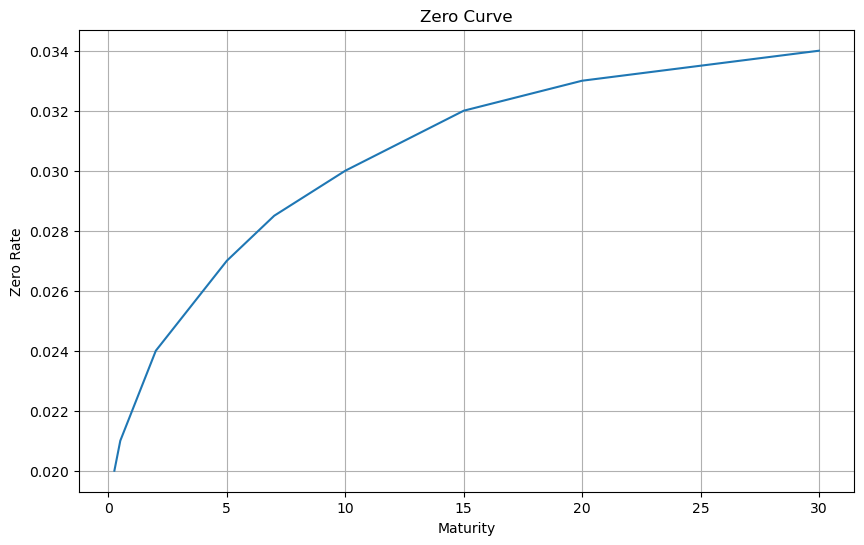

In [3]:
plot_zero_curve(
    maturities,
    rates
)

---
# 5. Discount Factors

Discount factors are computed as:

$$
DF(t) =
e^{-r(t)t}
$$

They represent:

> the present value of receiving 1 unit of currency at future time \(t\).

Discount factors are fundamental for all fixed income pricing systems.


In [4]:
test_times = [1, 2, 5, 10, 20, 30]

for t in test_times:

    df = curve.discount_factor(t)

    print(
        f"Maturity = {t:2d}Y | "
        f"Discount Factor = {df:.6f}"
    )


Maturity =  1Y | Discount Factor = 0.978240
Maturity =  2Y | Discount Factor = 0.953134
Maturity =  5Y | Discount Factor = 0.873716
Maturity = 10Y | Discount Factor = 0.740818
Maturity = 20Y | Discount Factor = 0.516851
Maturity = 30Y | Discount Factor = 0.360595


---
# 6. Floating Leg and Forward Rates

The floating leg depends on implied forward rates.

Forward rates are extracted from discount factors:

$$
F(t_1,t_2) =
\frac{
DF(t_1)
}{
DF(t_2)
}
-1
$$
divided by accrual:

$$
F(t_1,t_2) =
\frac{
\frac{DF(t_1)}{DF(t_2)}-1
}{
t_2-t_1
}
$$


Forward rates represent:

- future policy expectations
- expected funding rates
- market pricing of future liquidity

In [5]:
pairs = [
    (0.0, 0.5),
    (1.0, 1.5),
    (2.0, 2.5),
    (5.0, 5.5)
]

for t1, t2 in pairs:

    fwd = curve.forward_rate(t1, t2)

    print(
        f"Forward({t1:.1f},{t2:.1f}) "
        f"= {fwd:.4%}"
    )

Forward(0.0,0.5) = 2.1111%
Forward(1.0,1.5) = 2.5157%
Forward(2.0,2.5) = 2.6676%
Forward(5.0,5.5) = 3.1368%


---
# 7. Swap Pricing Theory

A swap consists of:
## Fixed Leg

Cashflow:

$$
CF_{fixed} =
N \times K \times \Delta
$$

where:

- $N$ = notional
- $K$ = fixed coupon
- $\Delta$ = accrual fraction


## Floating Leg

Cashflow:

$$
CF_{float} =
N \times F \times \Delta
$$

where:

- $F$ = implied forward rate

## Swap NPV

### Payer Swap

$$
NPV = PV_{float}-PV_{fixed}
$$

### Receiver Swap
$$
NPV = PV_{fixed} - PV_{float}
$$

---

# 8. Creating a 5Y Vanilla Swap

We now construct:

- 5Y maturity
- semiannual payments
- fixed coupon = 3%
- notional = 10 million

## Payment Schedule

Swap cashflows occur on payment dates.

For semiannual swaps:

$$
0.5,\ 1.0,\ 1.5,\ \dots
$$

Production systems use:

- business day calendars
- holiday adjustments
- stubs
- day count conventions

Our implementation uses simplified schedules.

---

In [6]:
swap = InterestRateSwap(
    notional=10_000_000,
    fixed_rate=0.03,
    maturity=5,
    payment_frequency=2,
    payer=True
)

print("Swap created successfully.")

Swap created successfully.


In [7]:
# Display Payment Dates

print("Payment Dates:")

for d in swap.payment_dates:

    print(d)

Payment Dates:
0.5
1.0
1.5
2.0
2.5
3.0
3.5
4.0
4.5
5.0


---
# 9. Fixed Leg Pricing

The fixed leg contains deterministic coupons.

Each coupon is:

$$
N \times K \times \Delta
$$

Discounted using:

$$
PV = CF \times DF
$$


In [9]:
fixed_pv = swap.fixed_leg.pv(curve)

print(f"Fixed Leg PV = ${fixed_pv:,.2f}")

Fixed Leg PV = $1,399,873.92


---
# 10. Floating Leg Pricing

The floating leg depends on implied forward rates.

Each coupon uses:

$$
F(t_i,t_{i+1})
$$

derived from the curve.

Floating legs are more sensitive to:

- interpolation
- curve smoothness
- market shocks


In [10]:
float_pv = swap.floating_leg.pv(curve)

print(f"Floating Leg PV = ${float_pv:,.2f}")

Floating Leg PV = $1,262,840.88


---
# 11. Swap Net Present Value (NPV) - Payer

For payer swaps:

$$
NPV = PV_{float} - PV_{fixed}
$$

Positive NPV means:

> receiving floating is favorable.

In [11]:
npv = swap.npv(curve)

print(f"Swap NPV = ${npv:,.2f}")

Swap NPV = $-137,033.04


---
# 12. Par Swap Rate

The par swap rate is the fixed coupon that makes:

$$
NPV = 0
$$

Formula:

$$
K = \frac{1-DF(T)}{\sum_i \Delta_i DF(t_i)}
$$

### Why It Matters:

Par swap rates are among the most quoted rates products globally.


In [12]:
par_rate = swap.par_swap_rate(curve)

print(f"Par Swap Rate = {par_rate:.4%}")

Par Swap Rate = 2.7063%


---
# 13. Receiver Swap

We now construct:

- receive fixed
- pay floating

This reverses swap exposure.

In [13]:
receiver_swap = InterestRateSwap(
    notional=10_000_000,
    fixed_rate=0.03,
    maturity=5,
    payment_frequency=2,
    payer=False
)

receiver_npv = receiver_swap.npv(curve)

print(f"Receiver Swap NPV = ${receiver_npv:,.2f}")

Receiver Swap NPV = $137,033.04


---
# 14. Curve Sensitivity

Swap values are highly sensitive to curve movements.

We now shock the curve upward by +50bp.

This simulates:

- inflation fears
- central bank tightening
- funding stress


## Step 1: Shock Curve

In [14]:
shocked_rates = rates + 0.005

shocked_curve = YieldCurve(
    maturities,
    shocked_rates
)

## Step 2: Reprice Swap

In [15]:
shocked_npv = swap.npv(shocked_curve)

print(f"Original NPV = ${npv:,.2f}")

print(f"Shocked NPV = ${shocked_npv:,.2f}")

print( f"PnL Change = ${shocked_npv - npv:,.2f}")

Original NPV = $-137,033.04
Shocked NPV = $97,375.26
PnL Change = $234,408.30


## Step3：NPV Sensitivity Plot

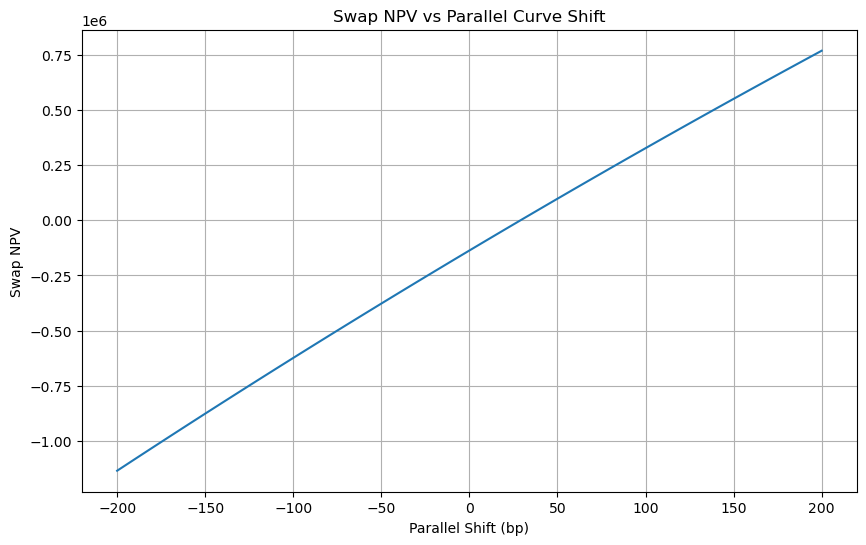

In [16]:
shifts = np.linspace(-0.02, 0.02, 41)

npvs = []

for s in shifts:

    shocked = YieldCurve(
        maturities,
        rates + s
    )

    npvs.append(
        swap.npv(shocked)
    )

plt.figure()

plt.plot(
    shifts * 10000,
    npvs
)

plt.title(
    "Swap NPV vs Parallel Curve Shift"
)

plt.xlabel(
    "Parallel Shift (bp)"
)

plt.ylabel(
    "Swap NPV"
)

plt.grid()

plt.show()

## Step 4：Risk Interpretation

Swaps are highly sensitive to:

- level shifts
- steepening
- flattening
- forward rate movements

Rates desks continuously monitor:

- DV01
- PV01
- key rate durations
- bucketed risk

### Why Risk Matters

Small curve changes can generate:

- large PnL swings
- hedge instability
- liquidity pressure
---

# 15. Summary

In this chapter we implemented:

- swap pricing
- fixed legs
- floating legs
- par swap rates
- payer swaps
- receiver swaps
- curve sensitivity


## Quant Engineering Notes

Production swap systems require:

- robust schedules
- calendars
- day count conventions
- interpolation frameworks
- multi-curve support

Real-world pricing systems are significantly more complex.


## Important Engineering Insight

Most pricing discrepancies come from:

- conventions
- schedules
- interpolation
- curve construction

NOT from formulas.

This is extremely important in FO quant development.


- This chapter is one of the core building blocks of rates quant finance.
